<a href="https://colab.research.google.com/github/tharindidinuja-lang/customer-churn-analysis/blob/main/task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset  (2).csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (7043, 21)

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 no

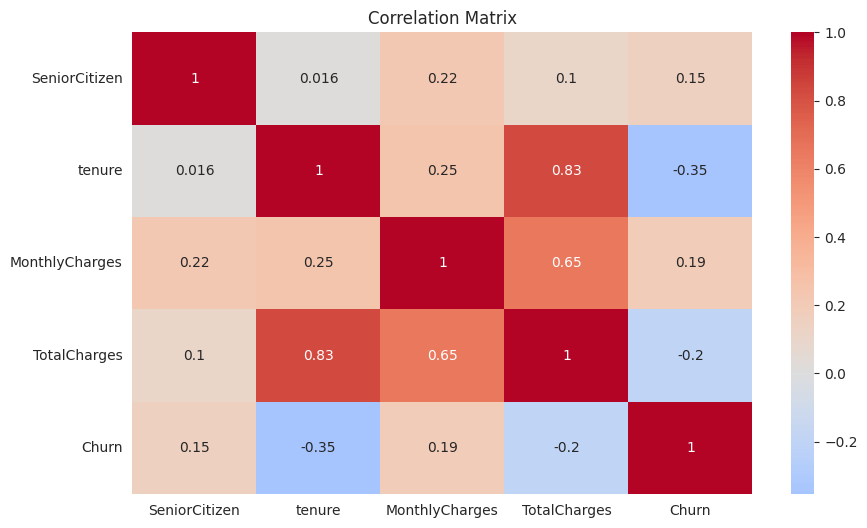

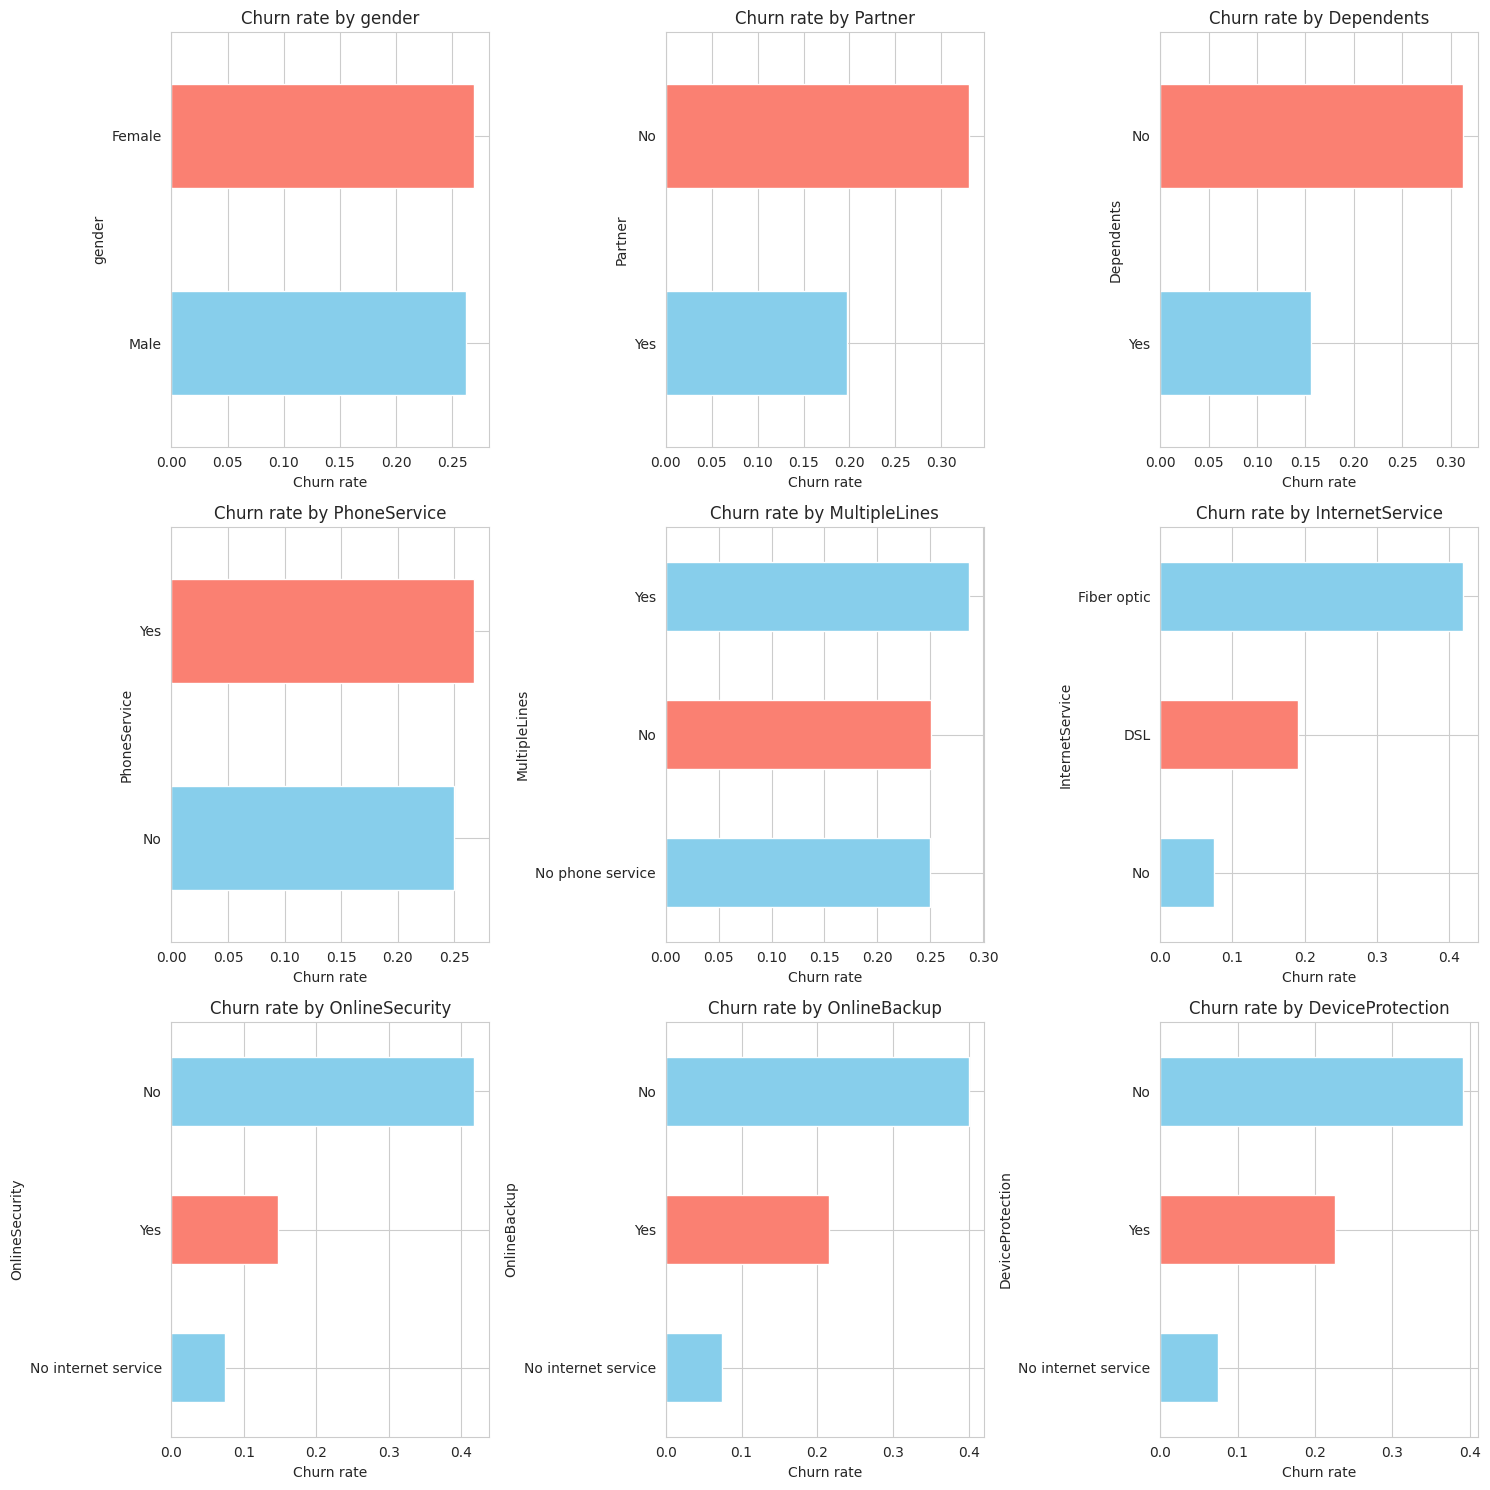

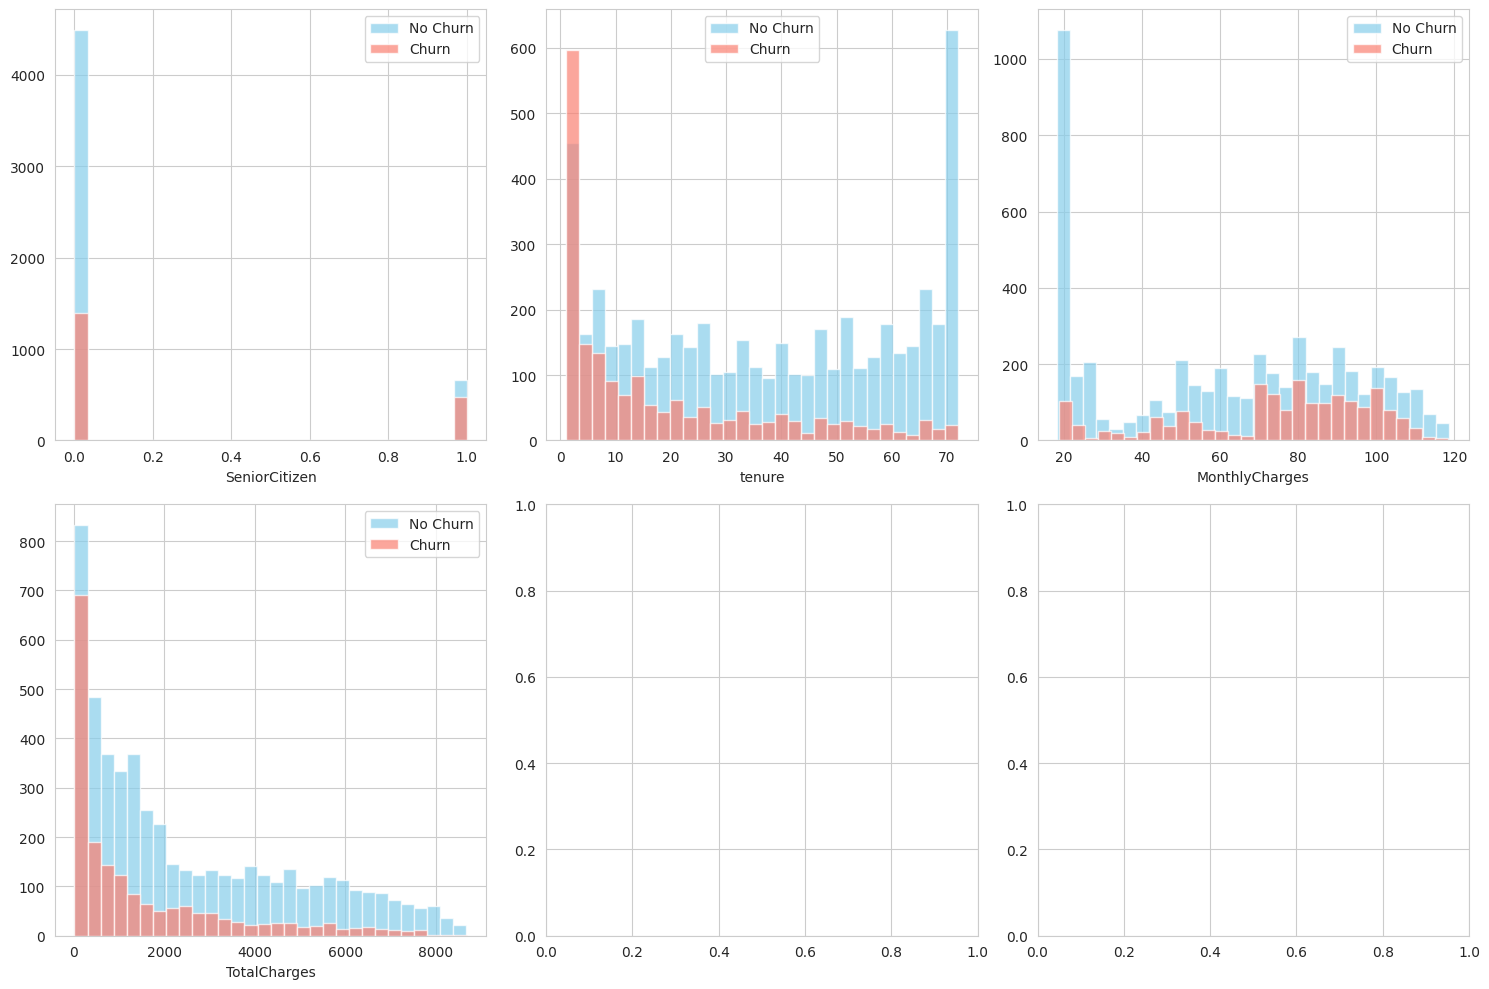

Training set size: (5625, 19)
Test set size: (1407, 19)

 Training set churn rate: 26.58%

 Test set churn rate: 26.58%
Features scaled completed
Logistic regression performance:
Accuracy: 0.7932
Precision: 0.6231
Recall: 0.5615
F1-Score: 0.5907
ROC-AUC: 0.8345


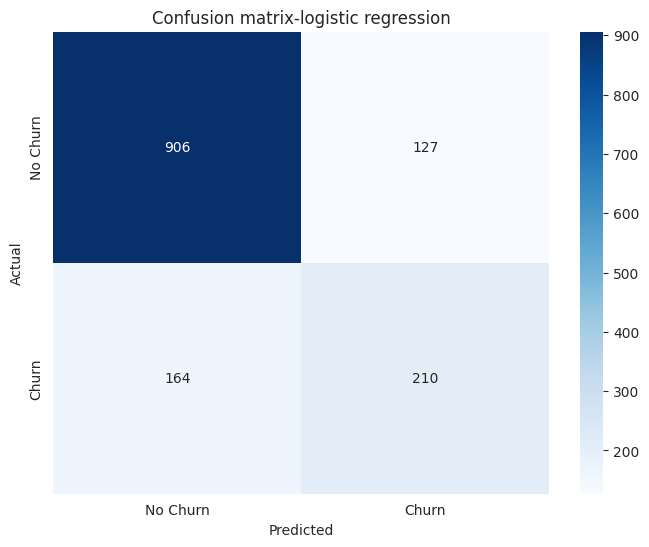

Detailed classification report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



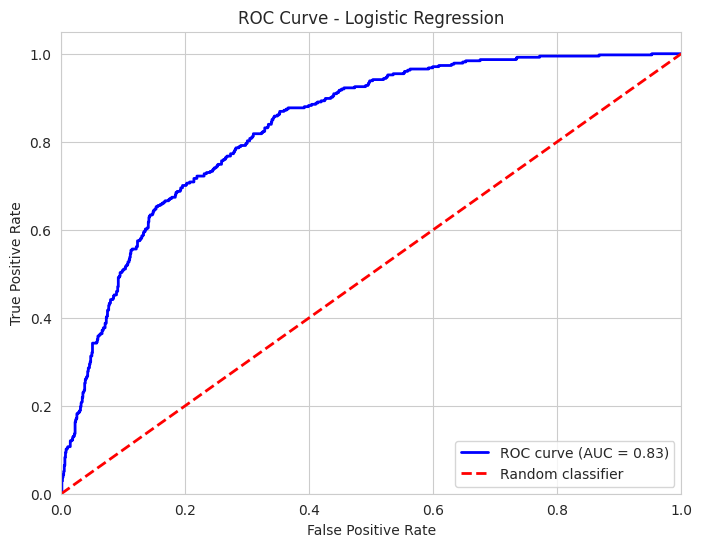

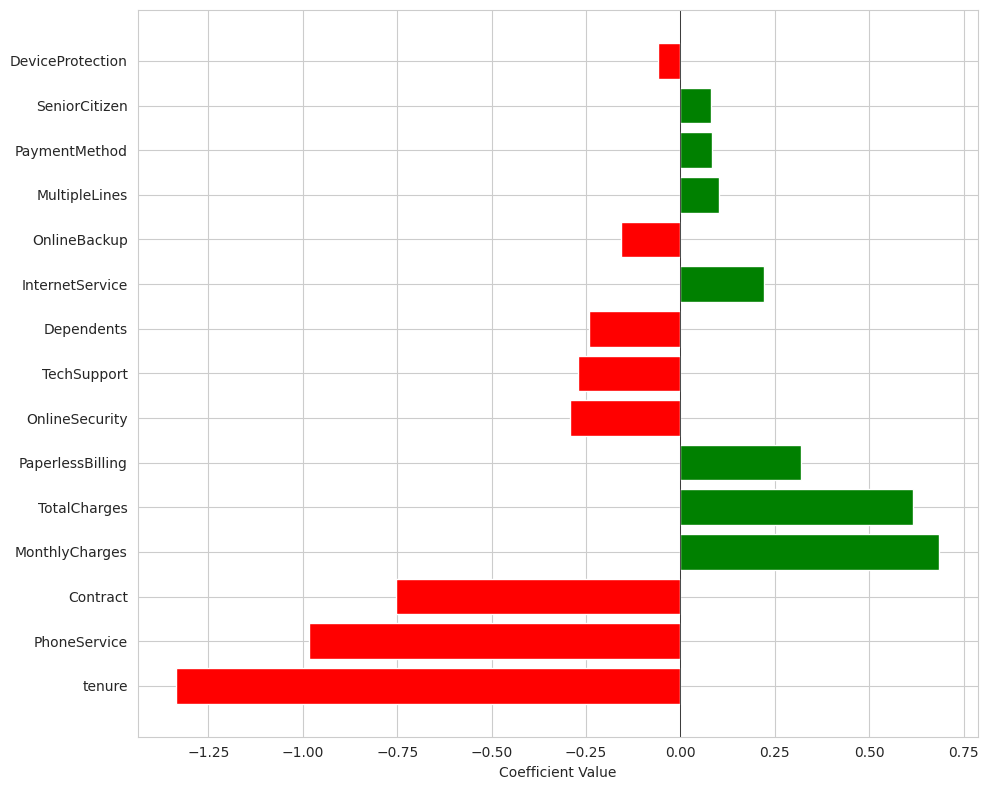

cross-validation results:
cv scores:[0.83421129 0.87205941 0.84382162 0.818738   0.8573858 ]
Mean cv score:0.8452(+/-0.0368)
Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cv score: 0.845342019807753

 Tuned model performance:
Accuracy: 0.7939
Precision: 0.6243
Recall: 0.5642
F1-Score: 0.5927
ROC-AUC: 0.8347
Random forest performance:
Accuracy: 0.7811
Precision: 0.6130
Recall: 0.4786
F1-Score: 0.5375
ROC-AUC: 0.8107
Models Comparison:
                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0        Logistic Regression    0.7932     0.6231  0.5615    0.5907   0.8345
1  Tuned Logistic Regression    0.7939     0.6243  0.5642    0.5927   0.8347
2              Random Forest    0.7811     0.6130  0.4786    0.5375   0.8107
Model saved succefully!!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

from google.colab import files
uploaded=files.upload()


#mount google drive to access your dataset
from google.colab import drive
drive.mount('/content/drive')

#data visuvalization
import matplotlib.pyplot as plt
import seaborn as sns

#machine leaining
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix, classification_report,roc_curve,roc_auc_score
from sklearn.ensemble import RandomForestClassifier # Added import for RandomForestClassifier

#image warnings
import warnings
warnings.filterwarnings('ignore')

#set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

import pandas as pd

#load the data sets
df=pd.read_csv('/content/Telco_Customer_Churn_Dataset .csv')
#display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


#basic dataset info
print(df.info())
print("\n"+"="*50)
print("\nStatistical summary:")
df.describe()

#check for missing values
print("Missing values:")
print(df.isnull().sum())

#check churn distribution
print("Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate:{df['Churn'].value_counts(normalize=True)[1]*100:.2f}%")


#handle missing values in totalcharges
print(f"Rows with empty TotalCharges:{df[df['TotalCharges']==' '].shape[0]}") # Changed '' to ' ' based on common dataset issues
df=df[df['TotalCharges']!=' '].copy() # Changed '' to ' '
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])
print(f"Dataset shape after clearning:{df.shape}")

#drop customerID as it's not useful for prediction
df=df.drop('customerID',axis=1)

#convert churn a binary
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

#display the cleaned data
df.head()

#separate features by type
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()
numerical_cols=df.select_dtypes(include=['int64','float64']).columns.tolist()
if 'Churn' in numerical_cols: # Check if 'Churn' is in numerical_cols before attempting to remove
    numerical_cols.remove('Churn') # remove target varibale

print("Categorical columns:",categorical_cols)
print("\nNumerical columns:",numerical_cols)

#encode categorical variables
le_dict={}
df_encoded=df.copy()
for col in categorical_cols:
    le=LabelEncoder() # Fixed typo: LabelEncoder instead of lebelEncoder
    df_encoded[col]=le.fit_transform(df_encoded[col])
    le_dict[col]=le # Fixed typo: le_dict instead of led_dict
df_encoded.head()

#correlation metrix for munerical features
plt.figure(figsize=(10,6))
correlation_matrix=df_encoded[numerical_cols+['Churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

#churn rate by categorical features
fig, axes=plt.subplots(3,3,figsize=(15,15))

for i, col in enumerate(categorical_cols[:9]):# first 9 categorical columns
    row = i // 3
    col_idx = i % 3
    churn_rate=df.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot(kind='barh',ax=axes[row, col_idx],color=['skyblue','salmon'])
    axes[row, col_idx].set_xlabel('Churn rate') # Fixed typo: set_xlabel instead of set+xlabel
    axes[row, col_idx].set_title(f'Churn rate by {col}')

plt.tight_layout()
plt.show()

#distribution of numerical features by churn
fig, axes=plt.subplots(2,3,figsize=(15,10))
axes=axes.ravel()

for i, col in enumerate(numerical_cols):
    for churn_val,color,label in [(0,'skyblue','No Churn'), (1,'salmon','Churn')]: # Fixed typo: No Vhurn to No Churn
        subset=df[df['Churn']==churn_val][col]
        axes[i].hist(subset,alpha=0.7,bins=30,label=label,color=color)
        axes[i].legend()
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#seperate features and target
x=df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']

#split the data
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)
print(f"Training set size: {x_train.shape}")
print(f"Test set size: {x_test.shape}")
print(f"\n Training set churn rate: {y_train.mean() * 100:.2f}%")
print(f"\n Test set churn rate: {y_test.mean() * 100:.2f}%")

#scale numerical features
scaler=StandardScaler()
x_train_scaled=x_train.copy()
x_test_scaled=x_test.copy()

x_train_scaled[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
x_test_scaled[numerical_cols]=scaler.transform(x_test[numerical_cols])

print('Features scaled completed')

#step:7
#initialize and train logistic rgression model
lr_model=LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(x_train_scaled,y_train)

#make predictions
y_pred_lr=lr_model.predict(x_test_scaled)
y_pred_proba_lr=lr_model.predict_proba(x_test_scaled)[:, 1]

#calculate metrics
accuracy=accuracy_score(y_test,y_pred_lr)
precision=precision_score(y_test,y_pred_lr)
recall=recall_score(y_test,y_pred_lr)
f1=f1_score(y_test,y_pred_lr) # Corrected to use y_pred_lr for f1_score
roc_auc = roc_auc_score(y_test, y_pred_proba_lr) # Defined roc_auc before use

print("Logistic regression performance:")
print("="*40)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

#confusion matrix
cm=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
xticklabels=['No Churn', 'Churn'],
yticklabels=['No Churn', 'Churn'])
plt.title('Confusion matrix-logistic regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#classification report
print("Detailed classification report:")
print(classification_report(y_test, y_pred_lr,target_names=['No Churn', 'Churn']))

#roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#get feature importance form logistic regression coefficients
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lr_model.coef_[0]
})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False, key=abs)
plt.figure(figsize=(10,8)) # Fixed figsize syntax
colors=['red' if x< 0 else 'green' for x in feature_importance['Coefficient'].head(15)] # Fixed 'cofficient' typo
plt.barh(range(15),feature_importance['Coefficient'].head(15),color=colors) # Fixed 'cofficient' and 'colirs' typos
plt.yticks(range(15), feature_importance['Feature'].head(15)) # Changed to show Feature names
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

#perform 5 fold cross validation
cv_scores=cross_val_score(lr_model, x_train_scaled, y_train,cv=5, scoring='roc_auc') # Changed 'rocauc' to 'roc_auc'
print("cross-validation results:")
print(f"cv scores:{cv_scores}")
print(f"Mean cv score:{cv_scores.mean():.4f}(+/-{cv_scores.std()*2:.4f})")

#grid search for hyperparameter tuning
param_grid={'C':[0.01,0.1,1,10,100],'solver':['liblinear','lbfgs'],'penalty':['l1','l2']} # Changed 'c' to 'C'
grid_search=GridSearchCV(LogisticRegression(random_state=42,max_iter=1000),param_grid,cv=5,scoring='roc_auc',n_jobs=-1)
grid_search.fit(x_train_scaled,y_train) # Added fit for grid_search
print("Best Parameters:",grid_search.best_params_)
print("Best cv score:",grid_search.best_score_)

#evaluate tuned model
best_lr=grid_search.best_estimator_
y_pred_best=best_lr.predict(x_test_scaled)
y_pred_proba_best=best_lr.predict_proba(x_test_scaled)[:, 1]

print("\n Tuned model performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}") # Corrected to use y_pred_best for f1_score
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

#fandom forest model
rf_model=RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(x_train_scaled,y_train) # Changed to use scaled data for consistency
# predictions
y_pred_rf=rf_model.predict(x_test_scaled) # Changed to use scaled data
y_pred_proba_rf=rf_model.predict_proba(x_test_scaled)[:, 1] # Changed to use scaled data

#metrics
print("Random forest performance:")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}") # Corrected to use y_pred_rf for f1_score
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

#compare all models
models_comparison=pd.DataFrame({
    'Model': ['Logistic Regression', 'Tuned Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_score(y_test, y_pred_best), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision, precision_score(y_test, y_pred_best), precision_score(y_test, y_pred_rf)],
    'Recall': [recall, recall_score(y_test, y_pred_best), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1, f1_score(y_test, y_pred_best), f1_score(y_test, y_pred_rf)], # Corrected f1_score for tuned LR and RF
    'ROC-AUC': [roc_auc, roc_auc_score(y_test, y_pred_proba_best), roc_auc_score(y_test, y_pred_proba_rf)]

})
print("Models Comparison:")
print(models_comparison.round(4))

#save the best model
import joblib

#save model and preprocessors
joblib.dump(best_lr, 'churn_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_dict,'label_encoders.pkl')
print("Model saved succefully!!")

# download the model filles
from google.colab import files # Fixed 'filles' to 'files'
files.download('churn_prediction_model.pkl')
